<a href="https://colab.research.google.com/github/Adetayo047/Time-Series-Forecasting-with-LSTM-GRU-and-SimpleRNN/blob/main/Analysis_of_Meteorological_Factors_and_Lassa_Fever_Cases_in_Nigeria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

My intention is to use Lassa fever case data and Weather data from January 2017 till December 2021

The NCDC dataset consists of the weekly Lassa fever cases for all the states in Nigeria from 2018 - 2020 (Although, I hope to update it to include that of 2017 and 2021)

The weather dataset includes temperature, rainfall (precipitation) and relative humidity data for all the local governments in 6 Lassa fever prevalent states in Nigeria (Bauchi, Ebonyi, Edo, Ondo, Plateau and Taraba States) from 2017 to 2021.

Not all the LGAs have Lassa fever cases, I will send a list of the Local Governments with Lassa fever cases for the six states being considered to you later today

The data was recorded in an hourly format, hence, we might need to calculate the average to get the daily/ weekly data.

Thank you very much.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import glob

In [ ]:
ls

 BAUCHI.xlsx                                     local.xlsx
'BAUCHI.xlsx - Google Drive.html'                MainWeatherData.csv
 Book2.xlsx                                      nigeria.xlsx
 Book3.xlsx                                      nigeria.xltx
 humidity.xlsx                                   precipitation.xlsx
 lassa.csv                                       State.xlsx
'Lassa Fever Data Updated.xlsx'                  temperatureknow.xlsx
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.csv      temperature.xlsx
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.gsheet   weather.csv
 lasserWeather.csv                               weatherstate.csv


In [ ]:
import os
os.getcwd()

'/content/drive/MyDrive/mrs Phd/mrs Phd/new'

In [ ]:
cd ..


/content/drive/MyDrive/mrs Phd/mrs Phd


In [ ]:
cd mrs Phd


/content/drive/MyDrive/mrs Phd/mrs Phd


In [ ]:
cd mrs phd

[Errno 2] No such file or directory: 'mrs phd'
/content/drive/MyDrive/mrs Phd


In [ ]:
cd fwddata

/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata


In [ ]:
ls

2017/  2017-2020.xlsx  2017.zip  2019/  2019.zip  precipitation2022.xlsx


In [ ]:
#Working with the Weather Dataset
#### firstly we are dealing with the precipiation data over the span of three year i.e from 2017-2022

df1 = pd.read_excel("2017-2020.xlsx")
df2 = pd.read_excel("precipitation2022.xlsx")

display(df1.head(), df2.head())

,DATE,LOCATION,PRECIPITATION
0,01-JAN-2017 00,owaneast,0.0
1,02-JAN-2017 00,owaneast,0.0
2,03-JAN-2017 00,owaneast,0.0
3,04-JAN-2017 00,owaneast,0.0
4,05-JAN-2017 00,owaneast,0.0


,Date,Local Govt,Precipitation
0,01-JAN-2021 00,akuresouth,9.50
1,02-JAN-2021 00,akuresouth,12.16
2,03-JAN-2021 00,akuresouth,7.04
3,04-JAN-2021 00,akuresouth,4.58
4,05-JAN-2021 00,akuresouth,4.62


In [ ]:

#renaming some columns into a new name
df2=df2.rename(columns={'Date':'DATE', 'Local Govt': 'LGA', 'Precipitation':'PRECIPITATION'})
df1=df1.rename(columns={'DATE':'DATE', 'LOCATION': 'LGA', 'PRECIPITATION':'PRECIPITATION'})

In [ ]:
display(df1.head(), df2.head())

,DATE,LGA,PRECIPITATION
0,01-JAN-2017 00,owaneast,0.0
1,02-JAN-2017 00,owaneast,0.0
2,03-JAN-2017 00,owaneast,0.0
3,04-JAN-2017 00,owaneast,0.0
4,05-JAN-2017 00,owaneast,0.0


,DATE,LGA,PRECIPITATION
0,01-JAN-2021 00,akuresouth,9.50
1,02-JAN-2021 00,akuresouth,12.16
2,03-JAN-2021 00,akuresouth,7.04
3,04-JAN-2021 00,akuresouth,4.58
4,05-JAN-2021 00,akuresouth,4.62


In [ ]:
dfcom = [df1,df2]
me = pd.concat(dfcom)
me

,DATE,LGA,PRECIPITATION
0,01-JAN-2017 00,owaneast,0.0
1,02-JAN-2017 00,owaneast,0.0
2,03-JAN-2017 00,owaneast,0.0
3,04-JAN-2017 00,owaneast,0.0
4,05-JAN-2017 00,owaneast,0.0
...,...,...,...
13135,27-DEC-2021 00,lantangnorth,0.0
13136,28-DEC-2021 00,lantangnorth,0.0
13137,29-DEC-2021 00,lantangnorth,0.0
13138,30-DEC-2021 00,lantangnorth,0.0


In [ ]:
me = me.reindex(columns=['DATE','PRECIPITATION','LGA'])
me.head(600)

,DATE,PRECIPITATION,LGA
0,01-JAN-2017 00,0.00,owaneast
1,02-JAN-2017 00,0.00,owaneast
2,03-JAN-2017 00,0.00,owaneast
3,04-JAN-2017 00,0.00,owaneast
4,05-JAN-2017 00,0.00,owaneast
...,...,...,...
595,19-AUG-2018 00,0.05,owaneast
596,20-AUG-2018 00,12.06,owaneast
597,21-AUG-2018 00,20.53,owaneast
598,22-AUG-2018 00,4.01,owaneast


In [ ]:
ls

2017/  2017-2020.xlsx  2017.zip  2019/  2019.zip  precipitation2022.xlsx


In [ ]:
cd 2017

/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata/2017


In [ ]:
cd 2017

/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata/2017/2017


In [ ]:
ls

ABAKALIKI.csv   BARKIN.csv          ETSAKOCENTRAL.csv  JOSSOUTH.csv        OWONNORTH.csv
AFIKPO.csv      BAUCHI.csv          ETSAKOWEST.csv     KARIMLAMIDO.csv     TARABA.csv
AKOKOEDO.csv    BOKKOS.csv          EZZANORTH.csv      LANTANGNORTH.csv    TORO.csv
AKOKOSOUTH.csv  DASS.csv            EZZASOUTH.csv      LANTANGSOUTH.csv    UHUMWONDE.csv
AKURENORTH.csv  ESANCENTRAL.csv     IGUEBEN.csv        MANGU.csv           ZORO.csv
AKURESOUTH.csv  ESANNORTH-EAST.csv  IZZI.csv           ONICHA.csv
ALKALERI.csv    ESANSOUTH-EAST.csv  JALINGO.csv        OVIANORTH-EAST.csv
BAGORO.csv      ESANWEST-EAST.csv   JOSNORTH.csv       OWANEAST.csv


In [ ]:
os.getcwd()

'/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata/2017/2017'

In [ ]:
import os

me = os.listdir()
me

['ABAKALIKI.csv',
 'AFIKPO.csv',
 'AKOKOEDO.csv',
 'AKOKOSOUTH.csv',
 'AKURENORTH.csv',
 'AKURESOUTH.csv',
 'ALKALERI.csv',
 'BAGORO.csv',
 'BARKIN.csv',
 'BAUCHI.csv',
 'BOKKOS.csv',
 'ESANCENTRAL.csv',
 'DASS.csv',
 'ESANNORTH-EAST.csv',
 'ESANSOUTH-EAST.csv',
 'ESANWEST-EAST.csv',
 'ETSAKOCENTRAL.csv',
 'ETSAKOWEST.csv',
 'EZZANORTH.csv',
 'EZZASOUTH.csv',
 'IGUEBEN.csv',
 'IZZI.csv',
 'JOSNORTH.csv',
 'JALINGO.csv',
 'JOSSOUTH.csv',
 'KARIMLAMIDO.csv',
 'LANTANGNORTH.csv',
 'LANTANGSOUTH.csv',
 'MANGU.csv',
 'ONICHA.csv',
 'OVIANORTH-EAST.csv',
 'OWANEAST.csv',
 'OWONNORTH.csv',
 'TARABA.csv',
 'TORO.csv',
 'UHUMWONDE.csv',
 'ZORO.csv']

In [ ]:
#### firstly we are dealing with the Humidity data over the span of three year i.e from 2017-2022
path = '/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata/2017/2017'

# Use glob to retrieve a list of all the CSV file paths in the directory
all_files = glob.glob(path + "/*.csv")

In [ ]:
ls

ABAKALIKI.csv   BARKIN.csv          ETSAKOCENTRAL.csv  JOSSOUTH.csv        OWONNORTH.csv
AFIKPO.csv      BAUCHI.csv          ETSAKOWEST.csv     KARIMLAMIDO.csv     TARABA.csv
AKOKOEDO.csv    BOKKOS.csv          EZZANORTH.csv      LANTANGNORTH.csv    TORO.csv
AKOKOSOUTH.csv  DASS.csv            EZZASOUTH.csv      LANTANGSOUTH.csv    UHUMWONDE.csv
AKURENORTH.csv  ESANCENTRAL.csv     IGUEBEN.csv        MANGU.csv           ZORO.csv
AKURESOUTH.csv  ESANNORTH-EAST.csv  IZZI.csv           ONICHA.csv
ALKALERI.csv    ESANSOUTH-EAST.csv  JALINGO.csv        OVIANORTH-EAST.csv
BAGORO.csv      ESANWEST-EAST.csv   JOSNORTH.csv       OWANEAST.csv


In [ ]:

# Create an empty list to store the DataFrames
dfs = []


# Loop through each file path in the list and read the CSV file into a DataFrame
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)



# Concatenate all of the DataFrames together into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Print the resulting combined DataFrame
print(combined_df)

            DATE  HUMIDITY        LGA
0       1-Jan-17     299.6  ABAKALIKI
1       2-Jan-17     299.0  ABAKALIKI
2       3-Jan-17     299.4  ABAKALIKI
3       4-Jan-17     298.3  ABAKALIKI
4       5-Jan-17     300.8  ABAKALIKI
...          ...       ...        ...
28102  27-Dec-21     299.5       ZORO
28103  28-Dec-21     297.1       ZORO
28104  29-Dec-21     296.6       ZORO
28105  30-Dec-21     296.1       ZORO
28106  31-Dec-21     301.9       ZORO

[28107 rows x 3 columns]


In [ ]:
ls

ABAKALIKI.csv   BARKIN.csv          ETSAKOCENTRAL.csv  JOSSOUTH.csv        OWONNORTH.csv
AFIKPO.csv      BAUCHI.csv          ETSAKOWEST.csv     KARIMLAMIDO.csv     TARABA.csv
AKOKOEDO.csv    BOKKOS.csv          EZZANORTH.csv      LANTANGNORTH.csv    TORO.csv
AKOKOSOUTH.csv  DASS.csv            EZZASOUTH.csv      LANTANGSOUTH.csv    UHUMWONDE.csv
AKURENORTH.csv  ESANCENTRAL.csv     IGUEBEN.csv        MANGU.csv           ZORO.csv
AKURESOUTH.csv  ESANNORTH-EAST.csv  IZZI.csv           ONICHA.csv
ALKALERI.csv    ESANSOUTH-EAST.csv  JALINGO.csv        OVIANORTH-EAST.csv
BAGORO.csv      ESANWEST-EAST.csv   JOSNORTH.csv       OWANEAST.csv


In [ ]:
#### firstly we are dealing with the Humidity data over the span of three year i.e from 2017-2022
path = '/content/drive/MyDrive/mrs Phd/mrs Phd/fwddata/2019/2019'

# Use glob to retrieve a list of all the CSV file paths in the directory
all_files = glob.glob(path + "/*.csv")

In [ ]:
# Create an empty list to store the DataFrames
dfs = []


# Loop through each file path in the list and read the CSV file into a DataFrame
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)



# Concatenate all of the DataFrames together into a single DataFrame
combined = pd.concat(dfs, ignore_index=True)

# Print the resulting combined DataFrame
print(combined)

            DATE  HUMIDITY        LGA
0       1-Jan-19     299.6  ABAKALIKI
1       2-Jan-19     300.6  ABAKALIKI
2       3-Jan-19     298.7  ABAKALIKI
3       4-Jan-19     300.4  ABAKALIKI
4       5-Jan-19     299.3  ABAKALIKI
...          ...       ...        ...
40546  27-Dec-21     299.5       ZORO
40547  28-Dec-21     297.1       ZORO
40548  29-Dec-21     296.6       ZORO
40549  30-Dec-21     296.1       ZORO
40550  31-Dec-21     301.9       ZORO

[40551 rows x 3 columns]


In [ ]:
comb = [combined_df, combined]

# Concatenate all of the DataFrames together into a single DataFrame
prep = pd.concat(comb, ignore_index=True)

# Print the resulting combined DataFrame
print(prep)

            DATE  HUMIDITY        LGA
0       1-Jan-17     299.6  ABAKALIKI
1       2-Jan-17     299.0  ABAKALIKI
2       3-Jan-17     299.4  ABAKALIKI
3       4-Jan-17     298.3  ABAKALIKI
4       5-Jan-17     300.8  ABAKALIKI
...          ...       ...        ...
68653  27-Dec-21     299.5       ZORO
68654  28-Dec-21     297.1       ZORO
68655  29-Dec-21     296.6       ZORO
68656  30-Dec-21     296.1       ZORO
68657  31-Dec-21     301.9       ZORO

[68658 rows x 3 columns]


In [ ]:
prep.to_excel('humidityN.xlsx',index = False)

In [ ]:
me

['ABAKALIKI.csv',
 'AFIKPO.csv',
 'AKOKOEDO.csv',
 'AKOKOSOUTH.csv',
 'AKURENORTH.csv',
 'AKURESOUTH.csv',
 'ALKALERI.csv',
 'BAGORO.csv',
 'BARKIN.csv',
 'BAUCHI.csv',
 'BOKKOS.csv',
 'ESANCENTRAL.csv',
 'DASS.csv',
 'ESANNORTH-EAST.csv',
 'ESANSOUTH-EAST.csv',
 'ESANWEST-EAST.csv',
 'ETSAKOCENTRAL.csv',
 'ETSAKOWEST.csv',
 'EZZANORTH.csv',
 'EZZASOUTH.csv',
 'IGUEBEN.csv',
 'IZZI.csv',
 'JOSNORTH.csv',
 'JALINGO.csv',
 'JOSSOUTH.csv',
 'KARIMLAMIDO.csv',
 'LANTANGNORTH.csv',
 'LANTANGSOUTH.csv',
 'MANGU.csv',
 'ONICHA.csv',
 'OVIANORTH-EAST.csv',
 'OWANEAST.csv',
 'OWONNORTH.csv',
 'TARABA.csv',
 'TORO.csv',
 'UHUMWONDE.csv',
 'ZORO.csv']

In [ ]:
me.to_excel('precipitationN.xlsx',index = False)

AttributeError: ignored

In [ ]:
ls

 BAUCHI.xlsx                                     MainWeatherData.csv
'BAUCHI.xlsx - Google Drive.html'                nigeria.xlsx
 Book2.xlsx                                      nigeria.xltx
 Book3.xlsx                                      precipitation.xlsx
 humidity.xlsx                                   State.xlsx
 lassa.csv                                       temperatureknow.xlsx
'Lassa Fever Data Updated.xlsx'                  temperature.xlsx
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.csv      weather.csv
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.gsheet   weatherNew.csv
 lasserWeather.csv                               weatherstate.csv
 local.xlsx


In [ ]:
cd /content/drive/MyDrive/mrs Phd/mrs Phd/new

/content/drive/MyDrive/mrs Phd/mrs Phd/new


In [ ]:
# reading the data's in and merging them together
import pandas as pd
temp = pd.read_excel('temperature.xlsx')
humid = pd.read_excel('humidity.xlsx')
precip = pd.read_excel('precipitation.xlsx')

In [ ]:

temp.head()

,Date,Temperature,LGA
0,"Saturday, 22 April 2017",297.0,izzi
1,"Tuesday, 9 May 2017",297.0,izzi
2,"Sunday, 28 May 2017",297.0,izzi
3,"Friday, 23 June 2017",297.0,izzi
4,"Thursday, 27 July 2017",297.0,izzi


In [ ]:
temp['LGA'].unique().shape

(37,)

In [ ]:

temp.rename(columns= {'Date': 'DATE'}, inplace = True)

In [ ]:
display(temp.head(),humid.head(),precip.head())

,DATE,Temperature,LGA
0,"Saturday, 22 April 2017",297.0,izzi
1,"Tuesday, 9 May 2017",297.0,izzi
2,"Sunday, 28 May 2017",297.0,izzi
3,"Friday, 23 June 2017",297.0,izzi
4,"Thursday, 27 July 2017",297.0,izzi


,DATE,humidity,LGA
0,"Sunday, 1 January 2017",18.00,akurenorth
1,"Monday, 2 January 2017",20.50,akurenorth
2,"Tuesday, 3 January 2017",24.00,akurenorth
3,"Wednesday, 4 January 2017",20.25,akurenorth
4,"Thursday, 5 January 2017",24.25,akurenorth


,DATE,PRECIPITATION,LGA
0,"Sunday, 1 January 2017",0.0,Taraba
1,"Monday, 2 January 2017",0.0,Taraba
2,"Tuesday, 3 January 2017",0.0,Taraba
3,"Wednesday, 4 January 2017",0.0,Taraba
4,"Thursday, 5 January 2017",0.0,Taraba


In [ ]:
tem = pd.read_excel('temperature.xlsx')
tem.rename(columns= {'Date': 'DATE'}, inplace = True)
tem['DATE']

0         Saturday, 22 April 2017
1             Tuesday, 9 May 2017
2             Sunday, 28 May 2017
3            Friday, 23 June 2017
4          Thursday, 27 July 2017
                   ...           
66827      Thursday, 29 July 2021
66828       Monday, 2 August 2021
66829     Saturday, 7 August 2021
66830    Thursday, 19 August 2021
66831    Monday, 6 September 2021
Name: DATE, Length: 66832, dtype: object

In [ ]:
import pandas as pd
from datetime import datetime
# Function to get the week number for a given date within each year
def get_week_number_within_year(date_string):
    date_obj = datetime.strptime(date_string, "%A, %d %B %Y")
    return date_obj.isocalendar()[1]


tem['WeekNumber'] = tem['DATE'].apply(get_week_number_within_year)

# Add a new column 'Year' to the DataFrame
tem['Year'] = tem['DATE'].apply(lambda x: datetime.strptime(x, "%A, %d %B %Y").year)

# Sort the DataFrame by 'Year', 'WeekNumberWithinYear', and 'LGA'
tem.sort_values(by=['WeekNumber', 'LGA','Year'], inplace=True)

# Reset the index for better presentation (optional)
tem.reset_index(drop=True, inplace=True)

# Calculate the average temperature based on 'WeekNumberWithinYear' and 'LGA'
average_temperatures = tem.groupby(['WeekNumber', 'LGA','Year'])['Temperature'].mean().reset_index()

average_temperatures.sort_values(by='LGA', inplace=True)

# Reset the index for better presentation (optional)
average_temperatures.reset_index(drop=True, inplace=True)


temp = average_temperatures
temp.head(10)

,WeekNumber,LGA,Year,Temperature
0,1,Bauchi,2017,296.428571
1,6,Bauchi,2017,298.928571
2,36,Bauchi,2017,296.542857
3,36,Bauchi,2018,296.071429
4,36,Bauchi,2019,296.971429
5,36,Bauchi,2020,295.842857
6,36,Bauchi,2021,296.328571
7,37,Bauchi,2017,296.157143
8,37,Bauchi,2018,296.971429
9,37,Bauchi,2019,297.257143


In [ ]:
import pandas as pd
from datetime import datetime


# Function to get the week number for a given date within each year
def get_week_number_within_year(date_string):
    date_obj = datetime.strptime(date_string, "%A, %d %B %Y")
    return date_obj.isocalendar()[1]

# Add a new column 'WeekNumberWithinYear' to the DataFrame
humid['WeekNumber'] = humid['DATE'].apply(get_week_number_within_year)

# Add a new column 'MonthYear' to the DataFrame
humid['Year'] = humid['DATE'].apply(lambda x: datetime.strptime(x, "%A, %d %B %Y").year)


# Sort the DataFrame by 'MonthYear', 'WeekNumber', and 'LGA'
humid.sort_values(by=['Year', 'WeekNumber', 'LGA'], inplace=True)


# Calculate the average temperature based on 'WeekNumberWithinMonth' and 'LGA'
average_humidity = humid.groupby(['WeekNumber', 'LGA','Year'])['humidity'].mean().reset_index()

average_humidity.sort_values(by='LGA', inplace=True)

# Reset the index for better presentation (optional)
average_humidity.reset_index(drop=True, inplace=True)

# Print the updated DataFrame
humid=average_humidity
humid.head(10)

,WeekNumber,LGA,Year,humidity
0,1,Bauchi,2017,19.857143
1,35,Bauchi,2021,69.700000
2,36,Bauchi,2017,63.331429
3,36,Bauchi,2018,72.938571
4,36,Bauchi,2019,69.657143
5,36,Bauchi,2020,74.785714
6,36,Bauchi,2021,70.535714
7,37,Bauchi,2017,61.604286
8,37,Bauchi,2018,62.700000
9,37,Bauchi,2019,69.814286


In [ ]:
import pandas as pd
from datetime import datetime


# Function to get the week number for a given date within each year
def get_week_number_within_year(date_string):
    date_obj = datetime.strptime(date_string, "%A, %d %B %Y")
    return date_obj.isocalendar()[1]

# Add a new column 'WeekNumberWithinYear' to the DataFrame

precip['WeekNumber'] = precip['DATE'].apply(get_week_number_within_year)

# Add a new column 'MonthYear' to the DataFrame
precip['Year'] = precip['DATE'].apply(lambda x: datetime.strptime(x, "%A, %d %B %Y").year)


# Sort the DataFrame by 'MonthYear', 'WeekNumber', and 'LGA'
precip.sort_values(by=['Year', 'WeekNumber', 'LGA'], inplace=True)


# Calculate the average temperature based on 'WeekNumberWithinMonth' and 'LGA'
average_precip = precip.groupby(['WeekNumber', 'LGA','Year'])['PRECIPITATION'].mean().reset_index()

average_precip.sort_values(by='LGA', inplace=True)

# Reset the index for better presentation (optional)
average_precip.reset_index(drop=True, inplace=True)

# Print the updated DataFrame
precip=average_precip
precip.head(10)

,WeekNumber,LGA,Year,PRECIPITATION
0,1,Bauchi,2017,0.000000
1,33,Bauchi,2017,1.871429
2,33,Bauchi,2018,0.842857
3,33,Bauchi,2019,5.971429
4,33,Bauchi,2020,1.714286
5,33,Bauchi,2021,9.911429
6,34,Bauchi,2017,5.200000
7,34,Bauchi,2018,3.142857
8,34,Bauchi,2019,6.942857
9,34,Bauchi,2020,8.357143


In [ ]:
display(temp.shape, humid.shape, precip.shape)

(9432, 4)

(9694, 4)

(9121, 4)

In [ ]:
# Sort the dataframe by the "Salary" column in descending order
temp1 = temp.sort_values(by='LGA', ascending=False)
humid1 = humid.sort_values(by='LGA', ascending=False)
precip1 = precip.sort_values(by='LGA', ascending=False)

In [ ]:
display(temp1['LGA'].nunique(),humid1['LGA'].nunique(),precip1['LGA'].nunique())

37

37

37

In [ ]:
display(temp1['LGA'].unique(),humid1['LGA'].unique(),precip1['LGA'].unique())


array(['zoro', 'uhunmwonde', 'toro', 'owonorth', 'owaneast',
       'ovianorth-east', 'onicha', 'mangu', 'lantangsouth',
       'lantangnorth', 'karimlamido', 'jossouth', 'josnorth', 'jalingo',
       'izzi', 'igueben', 'ezzasouth', 'ezzanorth', 'etsakowest',
       'etsakocentral', 'esanwest-east', 'esansouth-east',
       'esannorth-east', 'esancentral', 'dass', 'bokkos', 'bogoro',
       'barkin', 'alkaleri', 'akuresouth', 'akurenorth', 'akokosouth',
       'akokoedo', 'afikpo', 'abakaliki', 'Taraba', 'Bauchi'],
      dtype=object)

array(['zoro', 'uhunmwonde', 'toro', 'owonorth', 'owaneast',
       'ovianorth-east', 'onicha', 'mangu', 'lantangsouth',
       'lantangnorth', 'karimlamido', 'jossouth', 'josnorth', 'jalingo',
       'izzi', 'igueben', 'ezzasouth', 'ezzanorth', 'etsakowest',
       'etsakocentral', 'esanwest-east', 'esansouth-east',
       'esannorth-east', 'esancentral', 'dass', 'bokkos', 'bogoro',
       'barkin', 'alkaleri', 'akuresouth', 'akurenorth', 'akokosouth',
       'akokoedo', 'afikpo', 'abakaliki', 'Taraba', 'Bauchi'],
      dtype=object)

array(['zoro', 'uhunmwonde', 'toro', 'owonorth', 'owaneast',
       'ovianorth-east', 'onicha', 'mangu', 'lantangsouth',
       'lantangnorth', 'karimlamido', 'jossouth', 'josnorth', 'jalingo',
       'izzi', 'igueben', 'ezzasouth', 'ezzanorth', 'etsakowest',
       'etsakocentral', 'esanwest-east', 'esansouth-east',
       'esannorth-east', 'esancentral', 'dass', 'bokkos', 'bogoro',
       'barkin', 'alkaleri', 'akuresouth', 'akurenorth', 'akokosouth',
       'akokoedo', 'afikpo', 'abakaliki', 'Taraba', 'Bauchi'],
      dtype=object)

In [ ]:
temp1['LGA'].unique()

array(['zoro', 'uhunmwonde', 'toro', 'owonorth', 'owaneast',
       'ovianorth-east', 'onicha', 'mangu', 'lantangsouth',
       'lantangnorth', 'karimlamido', 'jossouth', 'josnorth', 'jalingo',
       'izzi', 'igueben', 'ezzasouth', 'ezzanorth', 'etsakowest',
       'etsakocentral', 'esanwest-east', 'esansouth-east',
       'esannorth-east', 'esancentral', 'dass', 'bokkos', 'bogoro',
       'barkin', 'alkaleri', 'akuresouth', 'akurenorth', 'akokosouth',
       'akokoedo', 'afikpo', 'abakaliki', 'Taraba', 'Bauchi'],
      dtype=object)

In [ ]:
# Assuming you have three DataFrames: temp, humid, precip

# Convert unique 'LGA' values to lists
temp_lga_list = temp1['LGA'].unique().tolist()
humid_lga_list = humid1['LGA'].unique().tolist()
precip_lga_list = precip1['LGA'].unique().tolist()

# Check if 'LGA' lists are the same
are_lga_equal = temp_lga_list == humid_lga_list == precip_lga_list

if are_lga_equal:
    print("The 'LGA' unique values are the same in all three DataFrames.")
else:
    print("The 'LGA' unique values are not the same in all three DataFrames.")


The 'LGA' unique values are the same in all three DataFrames.


In [ ]:
bauchi_list = ['Dass', 'Tafawa Balewa', 'Zaki']
ebonyi_list = ['Afikpo North', 'Ebonyi']
edo_list = ['Owan East', 'Esan west', 'Esan southeast', 'Esan Northeast', 'Esan Central']
ondo_list = ['Owo', 'Ose']
plateau_list = ['Barkin Ladi', 'Bassa-plateau', 'Langtang North', 'Langtang South']
taraba_list = ['Bali']

combined_list = []

combined_list.extend(bauchi_list)
combined_list.extend(ebonyi_list)
combined_list.extend(edo_list)
combined_list.extend(ondo_list)
combined_list.extend(plateau_list)
combined_list.extend(taraba_list)

# Alternatively, you can use the + operator
# combined_list = bauchi_list + ebonyi_list + edo_list + ondo_list + plateau_list + taraba_list
combined_list = [item.lower() for item in combined_list]
print(combined_list)


['dass', 'tafawa balewa', 'zaki', 'afikpo north', 'ebonyi', 'owan east', 'esan west', 'esan southeast', 'esan northeast', 'esan central', 'owo', 'ose', 'barkin ladi', 'bassa-plateau', 'langtang north', 'langtang south', 'bali']


In [ ]:
is_present = any(temp1['LGA'].isin(combined_list))
is_present

True

In [ ]:
# item_list = ['item1', 'item2', 'item3']
# is_present_list = [(item, item in df['column'].tolist()) for item in item_list]

is_present_list = [(item, item in temp1['LGA'].tolist()) for item in combined_list]
is_present_list

[('dass', True),
 ('tafawa balewa', False),
 ('zaki', False),
 ('afikpo north', False),
 ('ebonyi', False),
 ('owan east', False),
 ('esan west', False),
 ('esan southeast', False),
 ('esan northeast', False),
 ('esan central', False),
 ('owo', False),
 ('ose', False),
 ('barkin ladi', False),
 ('bassa-plateau', False),
 ('langtang north', False),
 ('langtang south', False),
 ('bali', False)]

In [ ]:
merged_df1

,WeekNumber_x,LGA,Temperature,WeekNumber_y,humidity
0,53,zoro,301.585714,53,22.597143
1,53,zoro,301.585714,20,65.625429
2,53,zoro,301.585714,31,80.812000
3,53,zoro,301.585714,32,81.056286
4,53,zoro,301.585714,21,65.692286
...,...,...,...,...,...
103875,1,Bauchi,295.625714,50,18.208571
103876,1,Bauchi,295.625714,5,13.848571
103877,1,Bauchi,295.625714,20,45.026571
103878,1,Bauchi,295.625714,15,32.368571


In [ ]:
temp1

,WeekNumber,LGA,Year,Temperature
9431,53,zoro,2021,301.733333
9323,37,zoro,2021,296.414286
9330,41,zoro,2019,296.228571
9329,42,zoro,2019,296.057143
9328,3,zoro,2019,299.857143
...,...,...,...,...
170,16,Bauchi,2021,302.542857
169,16,Bauchi,2020,303.428571
168,16,Bauchi,2019,300.385714
167,16,Bauchi,2018,301.528571


In [ ]:
import pandas as pd
# merge the dataframes on the 'key1' and 'key2' columns
merged_df1 = pd.merge(temp1, humid1, on=['LGA', 'WeekNumber', 'Year'], how='outer')
# merge the dataframes on the 'key1' and 'key2' columns
merged_dfA1 = pd.merge(precip1, merged_df1, on=['LGA', 'WeekNumber', 'Year'], how='outer')
merged_dfA1

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity
0,53,zoro,2021,0.013333,301.733333,24.650000
1,44,zoro,2021,8.938571,297.500000,65.107143
2,32,zoro,2020,0.377143,295.242857,80.447143
3,32,zoro,2019,6.627143,294.628571,85.660000
4,32,zoro,2018,0.731429,NaN,78.282857
...,...,...,...,...,...,...
9689,3,akokosouth,2017,NaN,299.614286,63.250000
9690,5,akokosouth,2017,NaN,300.600000,68.642857
9691,18,akokosouth,2017,NaN,299.771429,74.535714
9692,13,akokosouth,2017,NaN,303.400000,71.692857


In [ ]:
merged_dfA1.to_csv('weatherNew.csv', index = False)

In [ ]:
cd /content/drive/MyDrive/mrs Phd/mrs Phd/new

/content/drive/MyDrive/mrs Phd/mrs Phd/new


In [ ]:
ls

 BAUCHI.xlsx                                     MainWeatherData.csv
'BAUCHI.xlsx - Google Drive.html'                nigeria.xlsx
 Book2.xlsx                                      nigeria.xltx
 Book3.xlsx                                      precipitation.xlsx
 humidity.xlsx                                   State.xlsx
 lassa.csv                                       temperatureknow.xlsx
'Lassa Fever Data Updated.xlsx'                  temperature.xlsx
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.csv      weather.csv
 Lassa_LGA_2012-2019_WER-SitRep_Mar2021.gsheet   weatherNew.csv
 lasserWeather.csv                               weatherstate.csv
 local.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
cd /content/drive/MyDrive/mrs Phd/mrs Phd/new

/content/drive/MyDrive/mrs Phd/mrs Phd/new


In [ ]:
merged_dfA1 = pd.read_csv('weatherNew.csv')

In [ ]:
merged_dfA1

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity
0,53,zoro,2021,0.013333,301.733333,24.650000
1,44,zoro,2021,8.938571,297.500000,65.107143
2,32,zoro,2020,0.377143,295.242857,80.447143
3,32,zoro,2019,6.627143,294.628571,85.660000
4,32,zoro,2018,0.731429,NaN,78.282857
...,...,...,...,...,...,...
9689,3,akokosouth,2017,NaN,299.614286,63.250000
9690,5,akokosouth,2017,NaN,300.600000,68.642857
9691,18,akokosouth,2017,NaN,299.771429,74.535714
9692,13,akokosouth,2017,NaN,303.400000,71.692857


In [ ]:
merged_dfA1['LGA'].nunique()

37

In [ ]:
merged_dfA1

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity
0,53,zoro,2021,0.013333,301.733333,24.650000
1,44,zoro,2021,8.938571,297.500000,65.107143
2,32,zoro,2020,0.377143,295.242857,80.447143
3,32,zoro,2019,6.627143,294.628571,85.660000
4,32,zoro,2018,0.731429,NaN,78.282857
...,...,...,...,...,...,...
9689,3,akokosouth,2017,NaN,299.614286,63.250000
9690,5,akokosouth,2017,NaN,300.600000,68.642857
9691,18,akokosouth,2017,NaN,299.771429,74.535714
9692,13,akokosouth,2017,NaN,303.400000,71.692857


In [ ]:
merged_dfA1['LGA'] = merged_dfA1['LGA'].str.title()
merged_dfA1

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity
0,53,Zoro,2021,0.013333,301.733333,24.650000
1,44,Zoro,2021,8.938571,297.500000,65.107143
2,32,Zoro,2020,0.377143,295.242857,80.447143
3,32,Zoro,2019,6.627143,294.628571,85.660000
4,32,Zoro,2018,0.731429,NaN,78.282857
...,...,...,...,...,...,...
9689,3,Akokosouth,2017,NaN,299.614286,63.250000
9690,5,Akokosouth,2017,NaN,300.600000,68.642857
9691,18,Akokosouth,2017,NaN,299.771429,74.535714
9692,13,Akokosouth,2017,NaN,303.400000,71.692857


In [ ]:
state = pd.read_excel("local.xlsx")

In [ ]:
state.head()

,LGA,State
0,alkaleri,BAUCHI
1,bauchi,BAUCHI
2,bogoro,BAUCHI
3,dambam,BAUCHI
4,darazo,BAUCHI


In [ ]:
state['LGA'] = state['LGA'].str.title()
state['State'] = state['State'].str.title()

In [ ]:
state.head()

,LGA,State
0,Alkaleri,Bauchi
1,Bauchi,Bauchi
2,Bogoro,Bauchi
3,Dambam,Bauchi
4,Darazo,Bauchi


In [ ]:
merged_dfA1['LGA'].nunique()

37

In [ ]:
display(merged_dfA1['LGA'].unique(),
state['LGA'].unique())

array(['Zoro', 'Uhunmwonde', 'Toro', 'Owonorth', 'Owaneast',
       'Ovianorth-East', 'Onicha', 'Mangu', 'Lantangsouth',
       'Lantangnorth', 'Karimlamido', 'Jossouth', 'Josnorth', 'Jalingo',
       'Izzi', 'Igueben', 'Ezzasouth', 'Ezzanorth', 'Etsakowest',
       'Etsakocentral', 'Esanwest-East', 'Esansouth-East',
       'Esannorth-East', 'Esancentral', 'Dass', 'Bokkos', 'Bogoro',
       'Barkin', 'Alkaleri', 'Akuresouth', 'Akurenorth', 'Akokosouth',
       'Akokoedo', 'Afikpo', 'Abakaliki', 'Taraba', 'Bauchi'],
      dtype=object)

array(['Alkaleri', 'Bauchi', 'Bogoro', 'Dambam', 'Darazo', 'Dass',
       'Gamawa', 'Ganjuwa', 'Giade', 'Itas/Gadau', "Jama'Are", 'Katagum',
       'Kirfi', 'Misau', 'Ningi', 'Shira', 'Tafawa Balewa', 'Toro',
       'Warji', 'Zaki', 'Abakaliki', 'Afikpo', 'Afikposouth', 'Ebonyi',
       'Ezzanorth', 'Ezzasouth', 'Ikwo', 'Ishielu', 'Ivo', 'Izzi',
       'Ohaozara', 'Ohaukwu', 'Onicha', 'Akokoedo', 'Egor', 'Edo',
       'Esancentral', 'Esannorth-East', 'Esansouth-East', 'Esanwest-East',
       'Etsakocentral', 'Etsakoeast', 'Etsakowest', 'Igueben',
       'Ikpoba/Okha', 'Oredo', 'Orhionmwon', 'Ovianorth-East',
       'Oviasouth-West', 'Owaneast', 'Owanwest', 'Uhunmwonde',
       'Akokonortheast', 'Akokonorthwest', 'Akokosoutheast', 'Akokosouth',
       'Akurenorth', 'Ondo', 'Akuresouth', 'Ese-Odo', 'Idanre', 'Ifedore',
       'Ilaje', 'Ileoluji/Okeigbo', 'Irele', 'Odigbo', 'Okitipupa',
       'Ondoeast', 'Ondowest', 'Ose', 'Owosouth', 'Owonorth', 'Barkin',
       'Bassa', 'Bokkos', 'Plat

In [ ]:
import pandas as pd

# Merge the DataFrames on the common column
result_df = pd.merge(merged_dfA1, state, how='inner', left_on='LGA', right_on='LGA')

# Get the unique common LGAs
unique_common_lgas = result_df['LGA'].unique()

# Display the result
print(unique_common_lgas)

['Zoro' 'Uhunmwonde' 'Toro' 'Owonorth' 'Owaneast' 'Ovianorth-East'
 'Onicha' 'Mangu' 'Lantangsouth' 'Lantangnorth' 'Karimlamido' 'Jossouth'
 'Josnorth' 'Jalingo' 'Izzi' 'Igueben' 'Ezzasouth' 'Ezzanorth'
 'Etsakowest' 'Etsakocentral' 'Esanwest-East' 'Esansouth-East'
 'Esannorth-East' 'Esancentral' 'Dass' 'Bokkos' 'Bogoro' 'Barkin'
 'Alkaleri' 'Akuresouth' 'Akurenorth' 'Akokosouth' 'Akokoedo' 'Afikpo'
 'Abakaliki' 'Taraba' 'Bauchi']


In [ ]:
result_df.head()

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity,State
0,53,Zoro,2021,0.013333,301.733333,24.650000,Anambra
1,44,Zoro,2021,8.938571,297.500000,65.107143,Anambra
2,32,Zoro,2020,0.377143,295.242857,80.447143,Anambra
3,32,Zoro,2019,6.627143,294.628571,85.660000,Anambra
4,32,Zoro,2018,0.731429,NaN,78.282857,Anambra


In [ ]:
result_df.shape

(9956, 7)

In [ ]:
state['State'].unique()

array(['Bauchi', 'Ebonyi', 'Edo', 'Ondo', 'Plateau', 'Taraba',
       'Anambra\xa0'], dtype=object)

In [ ]:
lassa['State'].unique()

array(['Ondo', 'Edo', 'Bauchi', 'Ebonyi', 'Plateau', 'Taraba'],
      dtype=object)

In [ ]:
lassa = pd.read_excel("Statebased Lassa fever.xlsx", sheet_name= 'All')
lassa.head()

,WeekNumber,Date,LasserFeverValue,Year,State
0,1,2017-01-03,0.0,2017,Ondo
1,2,2017-01-10,0.0,2017,Ondo
2,3,2017-01-17,0.0,2017,Ondo
3,4,2017-01-24,0.0,2017,Ondo
4,5,2017-01-31,2.0,2017,Ondo


In [ ]:
#here

In [ ]:
lassa['State'].unique()

array(['Ondo', 'Edo', 'Bauchi', 'Ebonyi', 'Plateau', 'Taraba'],
      dtype=object)

In [ ]:
state['State'].unique()

array(['Bauchi', 'Ebonyi', 'Edo', 'Ondo', 'Plateau', 'Taraba',
       'Anambra\xa0'], dtype=object)

In [ ]:
display(result_df.head(), lassa.head())

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity,State
0,53,Zoro,2021,0.013333,301.733333,24.650000,Anambra
1,44,Zoro,2021,8.938571,297.500000,65.107143,Anambra
2,32,Zoro,2020,0.377143,295.242857,80.447143,Anambra
3,32,Zoro,2019,6.627143,294.628571,85.660000,Anambra
4,32,Zoro,2018,0.731429,NaN,78.282857,Anambra


,WeekNumber,Date,LasserFeverValue,Year,State
0,1,2017-01-03,0.0,2017,Ondo
1,2,2017-01-10,0.0,2017,Ondo
2,3,2017-01-17,0.0,2017,Ondo
3,4,2017-01-24,0.0,2017,Ondo
4,5,2017-01-31,2.0,2017,Ondo


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# merging the state and the waether data together
weatherstate = pd.merge(result_df, lassa, on=['State', 'WeekNumber', 'Year'], how='inner')

In [ ]:
weatherstate['LGA'].unique()

array(['Uhunmwonde', 'Owaneast', 'Ovianorth-East', 'Igueben',
       'Etsakowest', 'Etsakocentral', 'Esanwest-East', 'Esansouth-East',
       'Esannorth-East', 'Esancentral', 'Akokoedo', 'Toro', 'Dass',
       'Bogoro', 'Alkaleri', 'Bauchi', 'Owonorth', 'Akuresouth',
       'Akurenorth', 'Akokosouth', 'Onicha', 'Izzi', 'Ezzasouth',
       'Ezzanorth', 'Afikpo', 'Abakaliki', 'Mangu', 'Lantangsouth',
       'Lantangnorth', 'Jossouth', 'Josnorth', 'Bokkos', 'Barkin',
       'Karimlamido', 'Jalingo', 'Taraba'], dtype=object)

In [ ]:
weatherstate['State'].replace({'Anambra\xa0': 'Anambra'}, inplace=True)


In [ ]:
weatherstate['State'].unique()

array(['Edo', 'Bauchi', 'Ondo', 'Ebonyi', 'Plateau', 'Taraba'],
      dtype=object)

In [ ]:
weatherstate

,WeekNumber,LGA,Year,PRECIPITATION,Temperature,humidity,State,Date,LasserFeverValue
0,29,Uhunmwonde,2018,12.771429,296.871429,89.048571,Edo,2018-07-22,5.0
1,29,Owaneast,2018,NaN,296.871429,89.048571,Edo,2018-07-22,5.0
2,29,Ovianorth-East,2018,19.175714,296.871429,89.048571,Edo,2018-07-22,5.0
3,29,Igueben,2018,12.542857,296.871429,89.048571,Edo,2018-07-22,5.0
4,29,Etsakowest,2018,12.542857,296.571429,81.775714,Edo,2018-07-22,5.0
...,...,...,...,...,...,...,...,...,...
9689,20,Jalingo,2019,0.024286,300.214286,41.672857,Taraba,2019-05-19,0.0
9690,20,Taraba,2019,3.167143,298.528571,64.858571,Taraba,2019-05-19,0.0
9691,36,Karimlamido,2018,8.325714,296.071429,72.938571,Taraba,2018-09-09,0.0
9692,36,Jalingo,2018,8.621429,296.685714,68.510000,Taraba,2018-09-09,0.0


In [ ]:
weatherstateF = weatherstate[['WeekNumber','Year','Date','PRECIPITATION','humidity','Temperature','LasserFeverValue','LGA','State']]

In [ ]:
weatherstateF

,WeekNumber,Year,Date,PRECIPITATION,humidity,Temperature,LasserFeverValue,LGA,State
0,29,2018,2018-07-22,12.771429,89.048571,296.871429,5.0,Uhunmwonde,Edo
1,29,2018,2018-07-22,NaN,89.048571,296.871429,5.0,Owaneast,Edo
2,29,2018,2018-07-22,19.175714,89.048571,296.871429,5.0,Ovianorth-East,Edo
3,29,2018,2018-07-22,12.542857,89.048571,296.871429,5.0,Igueben,Edo
4,29,2018,2018-07-22,12.542857,81.775714,296.571429,5.0,Etsakowest,Edo
...,...,...,...,...,...,...,...,...,...
9689,20,2019,2019-05-19,0.024286,41.672857,300.214286,0.0,Jalingo,Taraba
9690,20,2019,2019-05-19,3.167143,64.858571,298.528571,0.0,Taraba,Taraba
9691,36,2018,2018-09-09,8.325714,72.938571,296.071429,0.0,Karimlamido,Taraba
9692,36,2018,2018-09-09,8.621429,68.510000,296.685714,0.0,Jalingo,Taraba


In [ ]:
weatherstateF.to_csv('weatherstateDNew.csv', index =False)

In [ ]:
df = weatherstateF

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# convert the 'date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
#Creating the
df['Month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.week
df['day'] = df['Date'].dt.day

<ipython-input-65-875dbed4b9a4>:5: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['week'] = df['Date'].dt.week


In [ ]:
df

,WeekNumber,Year,Date,PRECIPITATION,humidity,Temperature,LasserFeverValue,LGA,State,Month,week,day
0,29,2018,2018-07-22,12.771429,89.048571,296.871429,5.0,Uhunmwonde,Edo,7,29,22
1,29,2018,2018-07-22,NaN,89.048571,296.871429,5.0,Owaneast,Edo,7,29,22
2,29,2018,2018-07-22,19.175714,89.048571,296.871429,5.0,Ovianorth-East,Edo,7,29,22
3,29,2018,2018-07-22,12.542857,89.048571,296.871429,5.0,Igueben,Edo,7,29,22
4,29,2018,2018-07-22,12.542857,81.775714,296.571429,5.0,Etsakowest,Edo,7,29,22
...,...,...,...,...,...,...,...,...,...,...,...,...
9689,20,2019,2019-05-19,0.024286,41.672857,300.214286,0.0,Jalingo,Taraba,5,20,19
9690,20,2019,2019-05-19,3.167143,64.858571,298.528571,0.0,Taraba,Taraba,5,20,19
9691,36,2018,2018-09-09,8.325714,72.938571,296.071429,0.0,Karimlamido,Taraba,9,36,9
9692,36,2018,2018-09-09,8.621429,68.510000,296.685714,0.0,Jalingo,Taraba,9,36,9


In [ ]:
#df = df.rename(columns={'PRECIPITATION': 'precipitation', 'humidity': 'Humidity'})
df = df.rename(columns={'precipitation': 'Precipitation'})

In [ ]:
df.isna().sum()

#df['lasserFeverValue'].astype(int)

WeekNumber          0
Year                0
Date                0
precipitation       0
Humidity            0
Temperature         0
LasserFeverValue    0
LGA                 0
State               0
Month               0
week                0
day                 0
dtype: int64

In [ ]:
df = df.fillna(0)

In [ ]:
df['LasserFeverValue'].astype(int)
df['Year'].astype(int)

0       2018
1       2018
2       2018
3       2018
4       2018
        ... 
9689    2019
9690    2019
9691    2018
9692    2018
9693    2018
Name: Year, Length: 9694, dtype: int64

In [ ]:
df.shape

(9694, 12)

In [ ]:
df.dtypes

WeekNumber                   int64
Year                         int64
Date                datetime64[ns]
Precipitation              float64
Humidity                   float64
Temperature                float64
LasserFeverValue           float64
LGA                         object
State                       object
Month                        int64
week                         int64
day                          int64
dtype: object

In [ ]:
df.describe()

,WeekNumber,Year,precipitation,Humidity,Temperature,LasserFeverValue,Month,week,day
count,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000
mean,26.702290,2019.011450,3.347012,55.033550,293.937902,2.085001,6.500000,26.526305,15.724778
std,15.128579,1.415589,4.636264,24.526845,37.911316,4.901253,3.465107,15.110907,8.845194
min,1.000000,2017.000000,0.000000,7.758571,0.000000,0.000000,1.000000,1.000000,1.000000
25%,14.000000,2018.000000,0.000000,31.572857,296.871429,0.000000,3.000000,13.000000,8.000000
50%,27.000000,2019.000000,1.055000,62.458571,298.357143,0.000000,6.500000,26.500000,16.000000
75%,40.000000,2020.000000,5.314286,75.321429,300.314286,2.000000,9.000000,40.000000,24.000000
max,53.000000,2021.000000,34.614286,90.864286,307.714286,42.000000,12.000000,53.000000,31.000000


In [ ]:
# select the columns for the meteorological factors and inlassafever cases
selected_columns = ['Precipitation', 'Humidity', 'Temperature', 'LasserFeverValue']
data_df = df[selected_columns]

# calculate the Pearson correlation coefficients matrix using the corr() method
correlation_matrix = data_df.corr(method='pearson')

# display the correlation matrix
print(correlation_matrix)

                  Precipitation  Humidity  Temperature  LasserFeverValue
Precipitation          1.000000  0.518236    -0.000926         -0.118865
Humidity               0.518236  1.000000     0.050114         -0.089100
Temperature           -0.000926  0.050114     1.000000          0.048046
LasserFeverValue      -0.118865 -0.089100     0.048046          1.000000


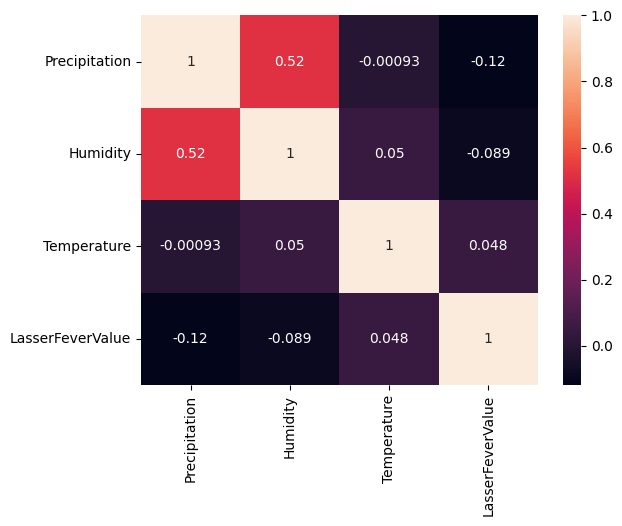

In [ ]:
# plot the heatmap of the correlation coefficients
sns.heatmap(correlation_matrix, annot=True)

# display the plot
plt.show()

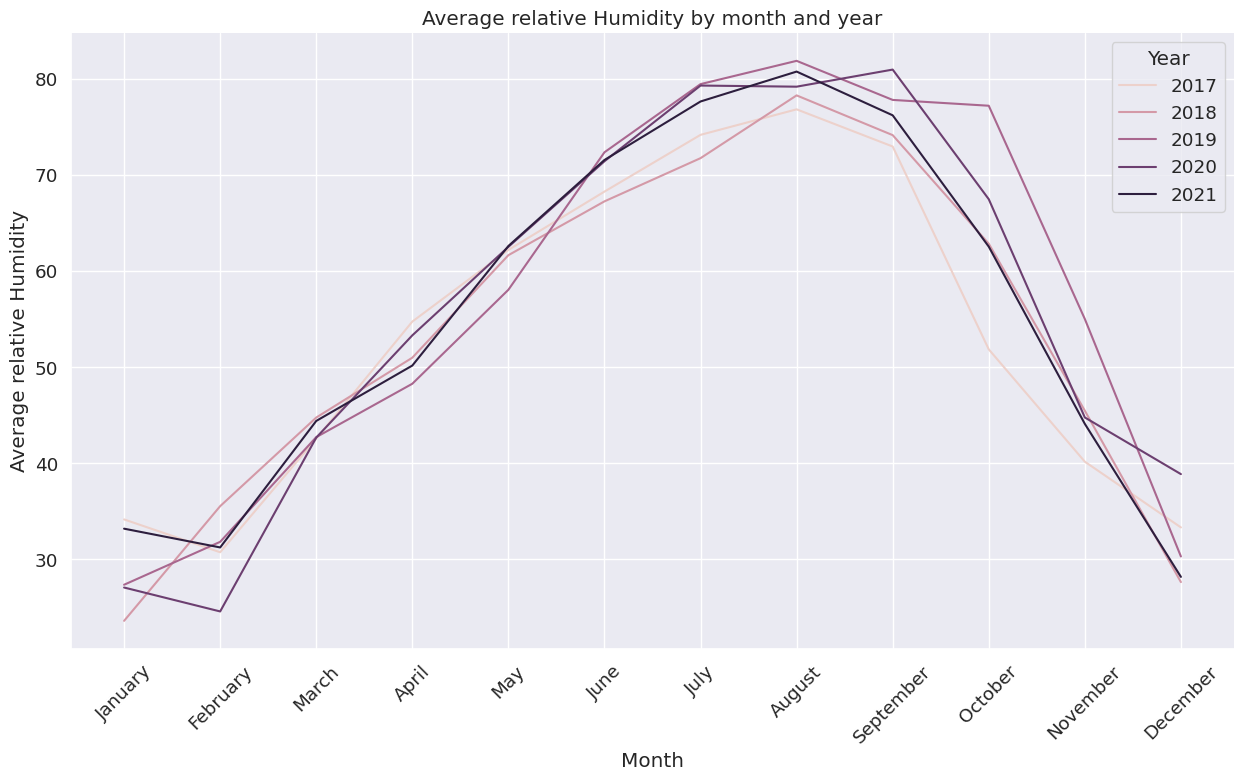

In [ ]:
import pandas as pd
import seaborn as sns
import calendar

# convert the 'date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# extract the  month from the 'date' column
df['Month'] = df['Date'].dt.month

# calculate the average relative humidity by year and month
avg_rel_humidity = df.groupby(['Year', 'Month'])['Humidity'].mean().reset_index()

# create a new column with month names
avg_rel_humidity['MonthName'] = avg_rel_humidity['Month'].apply(lambda x: calendar.month_name[x])

# create the visualization using seaborn
sns.lineplot(data=avg_rel_humidity, x='MonthName', y='Humidity', hue='Year')
sns.set(rc={'figure.figsize':(10, 7)})
sns.set(font_scale=1.2)
sns.set_palette("colorblind")
plt.xticks(rotation=45)
sns.despine()
plt.xlabel('Month')
plt.ylabel('Average relative Humidity')
plt.title('Average relative Humidity by month and year');


In [ ]:
# calculate the average relative humidity by year and month
avg_rel_humidity = df.groupby('Month')['Humidity'].mean().reset_index().sort_values(['Humidity'], ascending = False)
# create a new column with month names
avg_rel_humidity['MonthName'] = avg_rel_humidity['Month'].apply(lambda x: calendar.month_name[x])
avg_rel_humidity

,Month,Humidity,MonthName
7,8,79.433538,August
6,7,76.233863,July
8,9,76.221905,September
5,6,70.178345,June
9,10,64.431049,October
4,5,61.500709,May
3,4,51.458016,April
10,11,45.887245,November
2,3,43.334403,March
11,12,31.722687,December


In [ ]:
df.columns

Index(['WeekNumber', 'Year', 'Date', 'Precipitation', 'Humidity',
       'Temperature', 'LasserFeverValue', 'LGA', 'State', 'Month', 'week',
       'day'],
      dtype='object')

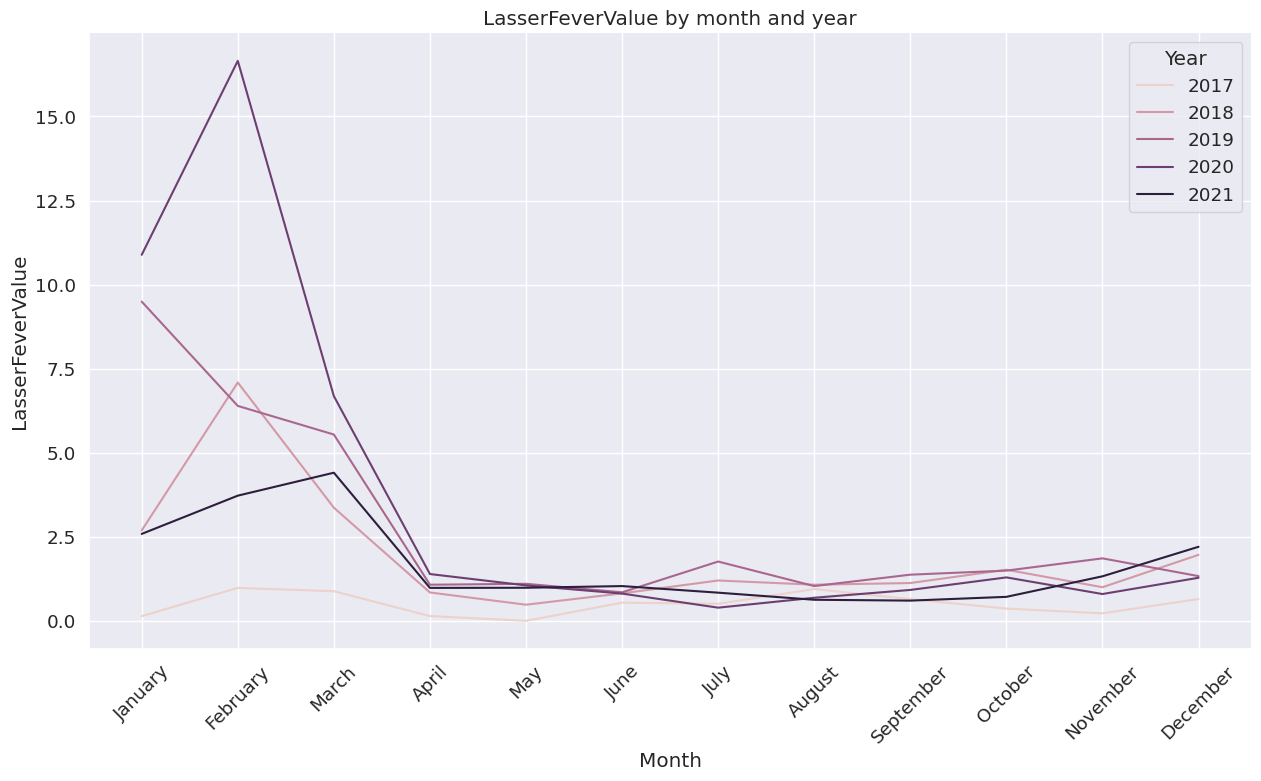

In [ ]:
import pandas as pd
import seaborn as sns
import calendar
import matplotlib.pyplot as plt

# Assuming you have a DataFrame named df with the required columns

# convert the 'date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# extract the month from the 'date' column
df['Month'] = df['Date'].dt.month

# calculate the average relative humidity by year and month
avg_rel_lasserFeverValue = df.groupby(['Year', 'Month'])['LasserFeverValue'].mean().reset_index()

# create a new column with month names
avg_rel_lasserFeverValue['MonthName'] = avg_rel_lasserFeverValue['Month'].apply(lambda x: calendar.month_name[x])

# create the visualization using seaborn
sns.lineplot(data=avg_rel_lasserFeverValue, x='MonthName', y='LasserFeverValue', hue='Year')
sns.set(rc={'figure.figsize':(15, 8)})
sns.set(font_scale=1.2)
sns.set_palette("colorblind")
sns.despine()

# rotate the y-axis labels
plt.xticks(rotation=45)

# add x-axis label, y-axis label, and a title
plt.xlabel('Month')
plt.ylabel('LasserFeverValue')
plt.title('LasserFeverValue by month and year')

plt.show()


In [ ]:
# calculate the average relative humidity by year and month
avg_rel_lasserFeverValue = df.groupby('Month')['lasserFeverValue'].mean().reset_index().sort_values(by = ['lasserFeverValue'], ascending = False)

# create a new column with month names
avg_rel_lasserFeverValue['MonthName'] = avg_rel_lasserFeverValue['Month'].apply(lambda x: calendar.month_name[x])
avg_rel_lasserFeverValue

,Month,lasserFeverValue,MonthName
0,1,0.443881,January
11,12,0.326750,December
1,2,0.311189,February
10,11,0.261427,November
4,5,0.256631,May
3,4,0.254160,April
9,10,0.247145,October
2,3,0.237686,March
8,9,0.198686,September
6,7,0.194836,July


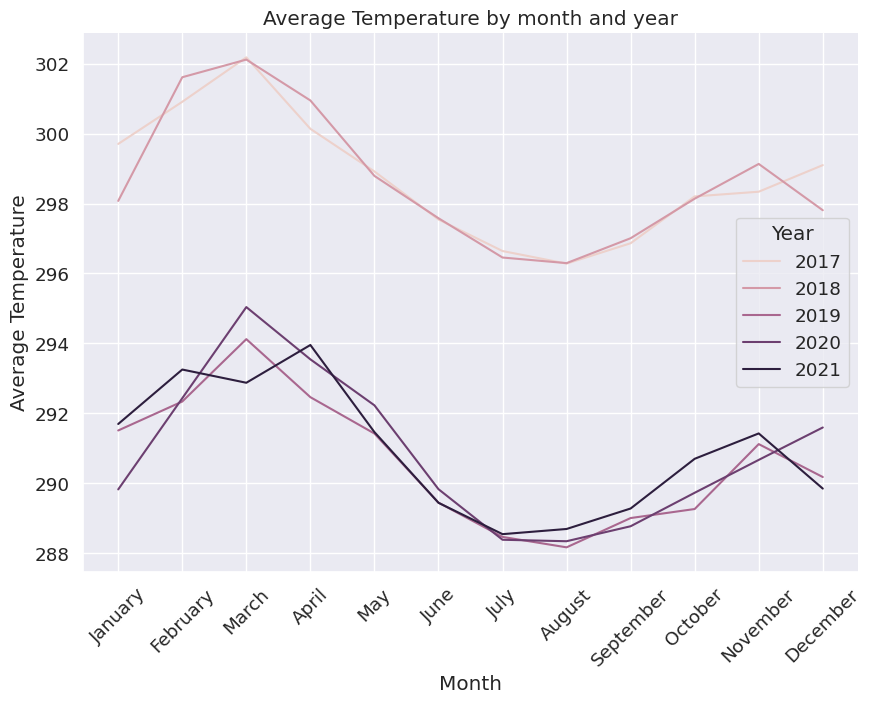

In [ ]:
# calculate the average relative humidity by year and month
avg_Temperature = df.groupby(['Year', 'Month'])['Temperature'].mean().reset_index()

# create a new column with month names
avg_Temperature['MonthName'] = avg_Temperature['Month'].apply(lambda x: calendar.month_name[x])

# create the visualization using seaborn
sns.lineplot(data=avg_Temperature, x='MonthName', y='Temperature', hue='Year')
sns.set(rc={'figure.figsize':(15, 6)})
sns.set(font_scale=1.2)
sns.set_palette("colorblind")
sns.despine()

plt.xticks(rotation=45)
# add x-axis label, y-axis label, and a title
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.title('Average Temperature by month and year');

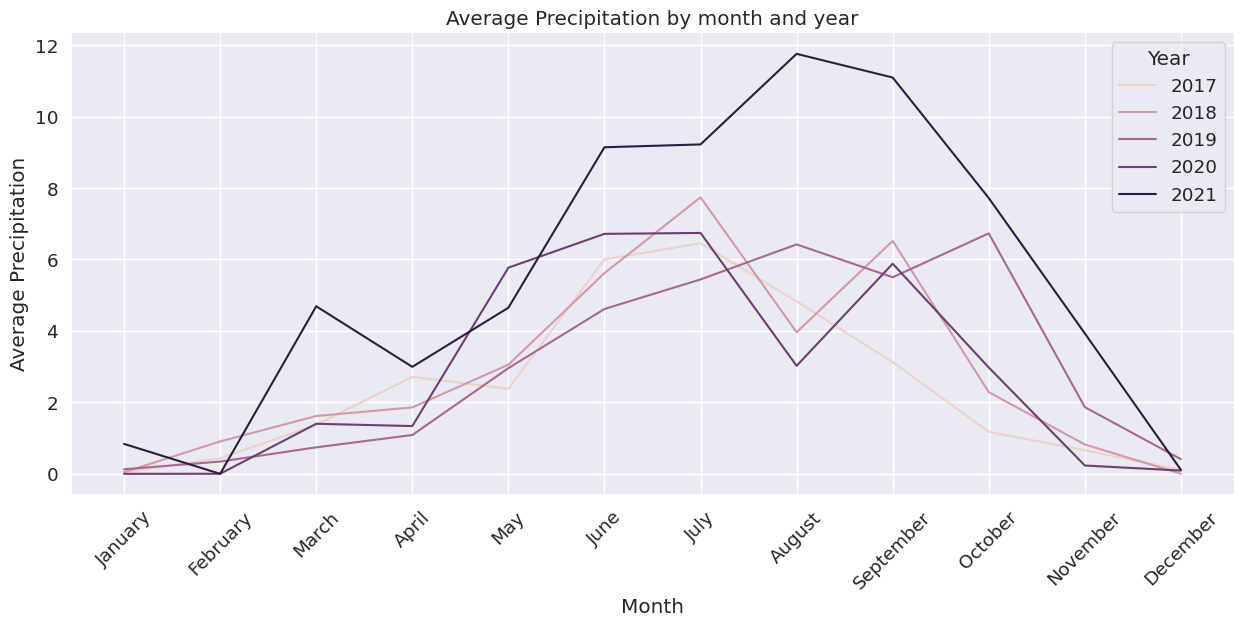

In [ ]:

# calculate the average relative humidity by year and month
avg_Precipitation = df.groupby(['Year', 'Month'])['Precipitation'].mean().reset_index()

# create a new column with month names
avg_Precipitation['MonthName'] = avg_Precipitation['Month'].apply(lambda x: calendar.month_name[x])

# create the visualization using seaborn
sns.lineplot(data=avg_Precipitation, x='MonthName', y='Precipitation', hue='Year')
sns.set(rc={'figure.figsize':(15,15)})
sns.set(font_scale=1.2)
sns.set_palette("colorblind")
sns.despine()

plt.xticks(rotation=45)
# add x-axis label, y-axis label, and a title
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.title('Average Precipitation by month and year');

In [ ]:
grouped = df.groupby('LGA')['LasserFeverValue'].sum()
grouped

LGA
Abakaliki          209.0
Afikpo             209.0
Akokoedo          1149.0
Akokosouth        1029.0
Akurenorth        1029.0
Akuresouth        1029.0
Alkaleri           173.0
Barkin             106.0
Bauchi             346.0
Bogoro             173.0
Bokkos             106.0
Dass               173.0
Esancentral       1149.0
Esannorth-East    1149.0
Esansouth-East    1149.0
Esanwest-East     1149.0
Etsakocentral     1149.0
Etsakowest        1149.0
Ezzanorth          209.0
Ezzasouth          209.0
Igueben           1149.0
Izzi               209.0
Jalingo            141.0
Josnorth           106.0
Jossouth           106.0
Karimlamido        141.0
Lantangnorth       106.0
Lantangsouth       106.0
Mangu              106.0
Onicha             209.0
Ovianorth-East    1149.0
Owaneast          1149.0
Owonorth          1029.0
Taraba             141.0
Toro               173.0
Uhunmwonde        1149.0
Name: LasserFeverValue, dtype: float64

In [ ]:
lgalassa = df.groupby(['LGA','State'])['LasserFeverValue'].mean().reset_index().sort_values(by=['LasserFeverValue'], ascending=False)
lgalassa

,LGA,State,LasserFeverValue
35,Uhunmwonde,Edo,4.385496
30,Ovianorth-East,Edo,4.385496
16,Etsakocentral,Edo,4.385496
15,Esanwest-East,Edo,4.385496
14,Esansouth-East,Edo,4.385496
13,Esannorth-East,Edo,4.385496
12,Esancentral,Edo,4.385496
20,Igueben,Edo,4.385496
17,Etsakowest,Edo,4.385496
31,Owaneast,Edo,4.385496


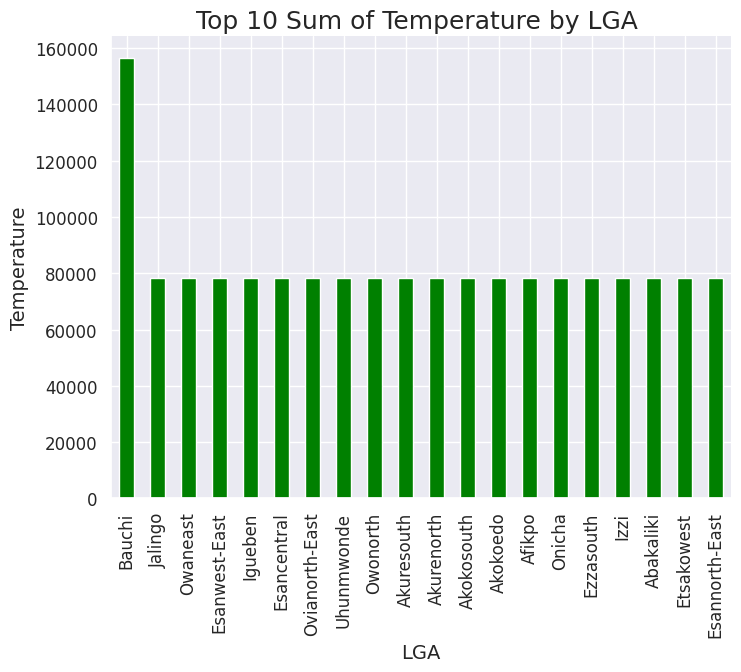

In [ ]:
# group the data by ProductName and calculate the sum of  AvgRatings for each group in other
# to get the product that has the highest Product price
grouped = df.groupby('LGA')['Temperature'].sum()

# sort the grouped data by sum of  ProductPrice
grouped_sorted = grouped.sort_values(ascending=False)

# get the top 20 values
top_10 = grouped_sorted.head(20)

# plot the top 5 values in a horizontal bar plot
fig, ax = plt.subplots(figsize=(8, 6))
top_10.plot(kind='bar', ax=ax, color='green')

# set the plot title and axis labels
ax.set_title('Top 10 Sum of Temperature by LGA ', fontsize=18)
ax.set_xlabel('LGA', fontsize=14)
ax.set_ylabel('Temperature', fontsize=14)

# style the plot
ax.tick_params(axis='both', which='major', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# display the plot
plt.show()

In [ ]:
grouped = df.groupby('Year')['Temperature'].sum()
grouped

Year
2017    574814.737500
2018    574536.669643
2019    559179.696429
2020    570395.171429
2021    570507.748571
Name: Temperature, dtype: float64

In [ ]:
df.columns

Index(['WeekNumber', 'Year', 'Date', 'Precipitation', 'Humidity',
       'Temperature', 'LasserFeverValue', 'LGA', 'State', 'Month', 'week',
       'day'],
      dtype='object')

In [ ]:
df.groupby('Month' 'day', 'WeekNumber')[['Precipitation', 'Temperature', 'Humidity']].mean()

ValueError: ignored

In [ ]:
df.groupby(['day'])[['Precipitation', 'Temperature', 'Humidity']].mean()


,Precipitation,Temperature,Humidity
day,,,
1,3.672960,293.536422,58.203728
2,6.801256,294.382515,57.527270
3,2.521410,294.951422,49.136234
4,3.254932,293.575560,55.190147
5,2.930270,292.231605,59.411065
6,4.344073,293.087629,58.706923
7,2.222189,294.507753,50.580870
8,3.074429,293.506006,57.594955
9,4.401093,294.218597,61.796905


In [ ]:
df

,WeekNumber,Year,Date,Precipitation,Humidity,Temperature,LasserFeverValue,LGA,State,Month,week,day
0,29,2018,2018-07-22,12.771429,89.048571,296.871429,5.0,Uhunmwonde,Edo,7,29,22
1,29,2018,2018-07-22,0.000000,89.048571,296.871429,5.0,Owaneast,Edo,7,29,22
2,29,2018,2018-07-22,19.175714,89.048571,296.871429,5.0,Ovianorth-East,Edo,7,29,22
3,29,2018,2018-07-22,12.542857,89.048571,296.871429,5.0,Igueben,Edo,7,29,22
4,29,2018,2018-07-22,12.542857,81.775714,296.571429,5.0,Etsakowest,Edo,7,29,22
...,...,...,...,...,...,...,...,...,...,...,...,...
9689,20,2019,2019-05-19,0.024286,41.672857,300.214286,0.0,Jalingo,Taraba,5,20,19
9690,20,2019,2019-05-19,3.167143,64.858571,298.528571,0.0,Taraba,Taraba,5,20,19
9691,36,2018,2018-09-09,8.325714,72.938571,296.071429,0.0,Karimlamido,Taraba,9,36,9
9692,36,2018,2018-09-09,8.621429,68.510000,296.685714,0.0,Jalingo,Taraba,9,36,9


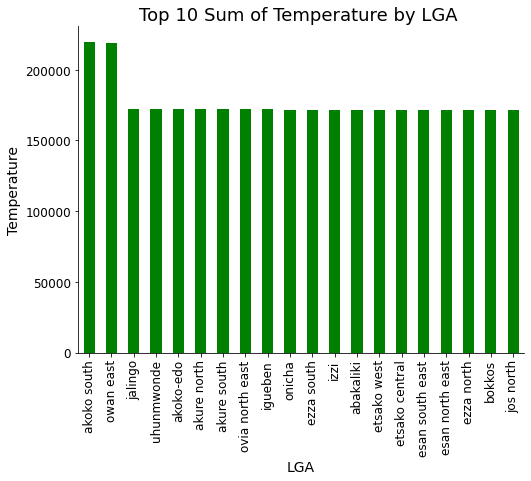

In [ ]:
# group the data by ProductName and calculate the sum of  AvgRatings for each group in other
# to get the product that has the highest Product price
grouped = df.groupby('LGA')['Temperature'].sum()

# sort the grouped data by sum of  ProductPrice
grouped_sorted = grouped.sort_values(ascending=False)

# get the top 20 values
top_10 = grouped_sorted.head(20)

# plot the top 5 values in a horizontal bar plot
fig, ax = plt.subplots(figsize=(8, 6))
top_10.plot(kind='bar', ax=ax, color='green')

# set the plot title and axis labels
ax.set_title('Top 10 Sum of Temperature by LGA ', fontsize=18)
ax.set_xlabel('LGA', fontsize=14)
ax.set_ylabel('Temperature', fontsize=14)

# style the plot
ax.tick_params(axis='both', which='major', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# display the plot
plt.show()

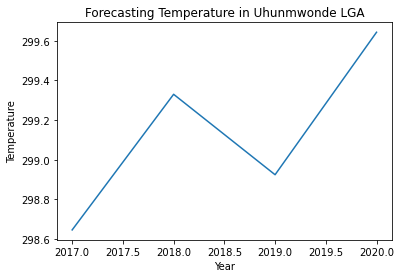

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d %m %Y')

# Set the Date column as the index
df.set_index('Date', inplace=True)

# Group the data by LGA and Year
df_grouped = df.groupby(['LGA', 'Year'])['Temperature'].mean().reset_index()

# Create a pivot table with LGA as rows and Year as columns
df_pivot = df_grouped.pivot(index='LGA', columns='Year', values='Temperature')


# Plot the forecast
plt.plot(df_pivot.loc['uhunmwonde'])
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('Forecasting Temperature in Uhunmwonde LGA')
plt.show()


In [ ]:
# Convert Date column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Group by month and calculate the mean
monthly_df = df.groupby(pd.Grouper(key='Date', freq='M'))[['Precipitation', 'Temperature', 'humidity']].mean()

# Show the resulting table
print(monthly_df)


            Precipitation  Temperature   humidity
Date                                             
2017-01-31       0.284057   300.244340  43.456887
2017-02-28       0.050074   299.520000  34.567259
2017-03-31       4.985970   300.829851  47.801940
2017-04-30       0.335556   299.310185  51.998796
2017-05-31       2.614476   298.870476  61.661238
2017-06-30       6.195714   299.187970  51.322180
2017-07-31       5.728558   296.731731  76.487596
2017-08-31       4.747925   296.999057  70.974906
2017-09-30       4.740096   297.216346  56.222212
2017-10-31       2.587000   298.081538  52.436846
2017-11-30       0.820519   297.865926  44.876667
2017-12-31       5.304125   298.683750  46.629250
2018-01-31       0.098017   298.700496  27.608545
2018-02-28       0.263546   300.760573  52.964626
2018-03-31       2.679870   299.838436  50.256221
2018-04-30       3.963860   299.892105  59.063596
2018-05-31       0.651052   299.640735  49.515643
2018-06-30       2.871605   296.688889  72.356543


In [ ]:
df

,Year,LGA,Precipitation,Temperature,humidity,lasserFeverStatus,State,lasserFeverValue,Month,week,day
Date,,,,,,,,,,,
2019-02-18,2019,uhunmwonde,0.0,302.6,41.03,SuspectedNegative,Edo,0.0,2,8,18
2019-02-18,2019,uhunmwonde,0.0,302.6,41.03,Confirmed,Edo,0.0,2,8,18
2019-01-21,2019,uhunmwonde,0.0,301.6,58.62,SuspectedNegative,Edo,1.0,1,4,21
2019-01-21,2019,uhunmwonde,0.0,301.6,58.62,Confirmed,Edo,0.0,1,4,21
2019-11-02,2019,uhunmwonde,0.0,300.9,14.76,SuspectedNegative,Edo,0.0,11,44,2
...,...,...,...,...,...,...,...,...,...,...,...
2019-11-02,2019,bauchi,0.0,296.8,17.76,Confirmed,Bauchi,2.0,11,44,2
2017-09-10,2017,bauchi,0.0,297.0,49.01,Confirmed,Bauchi,0.0,9,36,10
2017-09-10,2017,bauchi,0.0,297.0,49.01,SuspectedUnconfirmed,Bauchi,0.0,9,36,10


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Generate sample data
np.random.seed(0)
steps = 50
time = np.linspace(0, 10, steps)
data = np.sin(time) + np.random.normal(0, 0.1, steps)

# Split data into training and testing sets
train_data = data[:30]
test_data = data[30:]

# Create a data generator to prepare the data for training
def data_generator(data, lookback, delay, min_index, max_index, shuffle=False, batch_size=128, step=6):
    if max_index is None:
        max_index = len(data) - delay - 1
    i = min_index + lookback
    while 1:
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)
        samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
        targets = np.zeros((len(rows),))
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)
            samples[j] = data[indices]
            targets[j] = data[rows[j] + delay]
        yield samples, targets

# Set the hyperparameters
lookback = 10
step = 1
delay = 1
batch_size = 128

# Generate the training and validation data
train_gen = data_generator(train_data, lookback=lookback, delay=delay, min_index=0, max_index=None, shuffle=True, step=step, batch_size=batch_size)
val_gen = data_generator(train_data, lookback=lookback, delay=delay, min_index=0, max_index=None, step=step, batch_size=batch_size)
val_steps = (30 - lookback) // batch_size

# Create the LSTM model
model = Sequential()
model.add(LSTM(32, input_shape=(None, 1)))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='rmsprop', loss='mae')

# Train the model
history = model.fit_generator(train_gen, steps_per_epoch=500, epochs=40, validation_data=val_gen, validation_steps=val_steps)

# Plot the training and validation loss
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
plt.figure()
plt.plot(epoch)


In [ ]:
# prompt: give me a summary of this notebook

This notebook analyzes the relationship between meteorological factors (temperature, humidity, precipitation) and Lassa fever cases across different Local Government Areas (LGAs) and states in Nigeria.  It begins by cleaning and preprocessing weather data from multiple sources, ensuring consistent LGA names across datasets.  The data is then merged with Lassa fever case data, creating a comprehensive dataset.  Exploratory data analysis is performed, including correlation analysis between meteorological variables and Lassa fever cases, visualized using heatmaps. Time series visualizations show trends in humidity, Lassa fever cases, temperature and precipitation over months and years.  Finally, the notebook attempts to forecast temperature in a specific LGA using a basic LSTM model, and also shows the mean of precipitation, temperature, and humidity by month.  The data is prepared by grouping by LGA and year.


In [ ]:
# prompt: what title will you give this

Analysis of Meteorological Factors and Lassa Fever Cases in Nigeria
